## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# METEOR Interface (new simplified API)
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


## 2. Initialize and Train Emulator

The `MeteorInterface` handles all the complexity:
- Data loading from CMIP6
- Pattern scaling model training
- Noise model training
- Variable-specific transforms (precipitation → Gamma distribution)

In [2]:
# Create emulator for both temperature and precipitation
emulator = MeteorInterface.from_cmip6(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"TAS transform: {emulator.transforms['tas'].transform_type}")
print(f"PR transform: {emulator.transforms['pr'].transform_type} ")

Emulator created for: ['tas', 'pr']
TAS transform: None
PR transform: gamma 


In [3]:
# Train models (uses cached models if available)
emulator.train(auto=True, verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Cache file not found: ../cache/pattern_scaling/cmip6-NorESM2-MM-aer_pattern_scaling.pkl
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_tas_noise_model.pkl
      ✓ Using cached noise model
   ✅ TAS training complete

🔧 Training PR...
   → Training pattern scaling model...
      ⚠️  Cache miss: Cache file not found: ../cache/pattern_scaling/cmip6-NorESM2-MM-aer_pattern_scaling.pkl
🔧 Preparing pattern scaling training data for NorESM2-MM...


   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 751 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-pr_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/NorESM2-MM_pr_noise_model.pkl
      ✓ Using cached noise model
   → Fitting gamma transform...
      Reason: Ensure positive-only values (precipitation cannot be negative)
   ✅ PR training complete

✅ All variables trained successfully


## 3. Define Locations

**Regions (AR6):**
- NEU: Northern Europe
- GIC: Greenland/Iceland
- NSA: Northern South America
- EAS: East Asia

**Cities:**
- Oslo: 59.9°N, 10.8°E
- Delhi: 28.6°N, 77.2°E
- Santiago: -33.4°S, -70.7°W (289.3°E)
- Beijing: 39.9°N, 116.4°E

In [4]:
# Define regions and points
regions = ['NEU', 'GIC', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'GIC': 'Greenland/Iceland',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    'Santiago': {'lat': -33.4, 'lon': 289.3},  # -70.7°W = 289.3°E
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

print(f"Regions: {', '.join(regions)}")
print(f"Cities: {', '.join(cities.keys())}")

Regions: NEU, GIC, NSA, EAS
Cities: Oslo, Delhi, Santiago, Beijing


## 4. Generate Ensemble

Generate 100 realizations with:
- Global mean
- 4 regional means
- 4 point locations
- Heating degree days for temperature

In [5]:
# Build aggregation list
timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Generating {len(timeseries)} spatial aggregations:")
for ts in timeseries:
    print(f"  - {ts}")

Generating 9 spatial aggregations:
  - global
  - regional:NEU
  - regional:GIC
  - regional:NSA
  - regional:EAS
  - point:59.9,10.8
  - point:28.6,77.2
  - point:-33.4,289.3
  - point:39.9,116.4


In [6]:
# Generate ensemble
ensemble = emulator.generate(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=100,
    timeseries=timeseries,
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

print(f"\n✅ Ensemble generated!")
print(f"Variables: {ensemble.list_variables()}")
print(f"TAS timeseries: {len(ensemble['tas'].timeseries)} aggregations")
print(f"PR timeseries: {len(ensemble['pr'].timeseries)} aggregations")
print(f"TAS impacts: {ensemble['tas'].list_impacts()}")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 100

📊 Generating TAS...
   → Time series: 9 aggregations
11
12
113
114
115
22
141
123
142
      • global
      • regional:NEU
      • regional:GIC
      • regional:NSA
      • regional:EAS
      • point:59.9,10.8
      • point:28.6,77.2
      • point:-33.4,289.3
      • point:39.9,116.4


   → Computing impact metrics...
      ⚠️  meteor.impacts.DegreeDays not available
   ✅ TAS complete

📊 Generating PR...
   → Time series: 9 aggregations
11
12
113
114
115
22
141
123
142
      • global
      • regional:NEU
      • regional:GIC
      • regional:NSA
      • regional:EAS
      • point:59.9,10.8
      • point:28.6,77.2
      • point:-33.4,289.3
      • point:39.9,116.4
   ✅ PR complete

✅ Generation complete

✅ Ensemble generated!
Variables: ['tas', 'pr']
TAS timeseries: 9 aggregations
PR timeseries: 9 aggregations
TAS impacts: []


## 5. Plot 1: Global Temperature and Precipitation

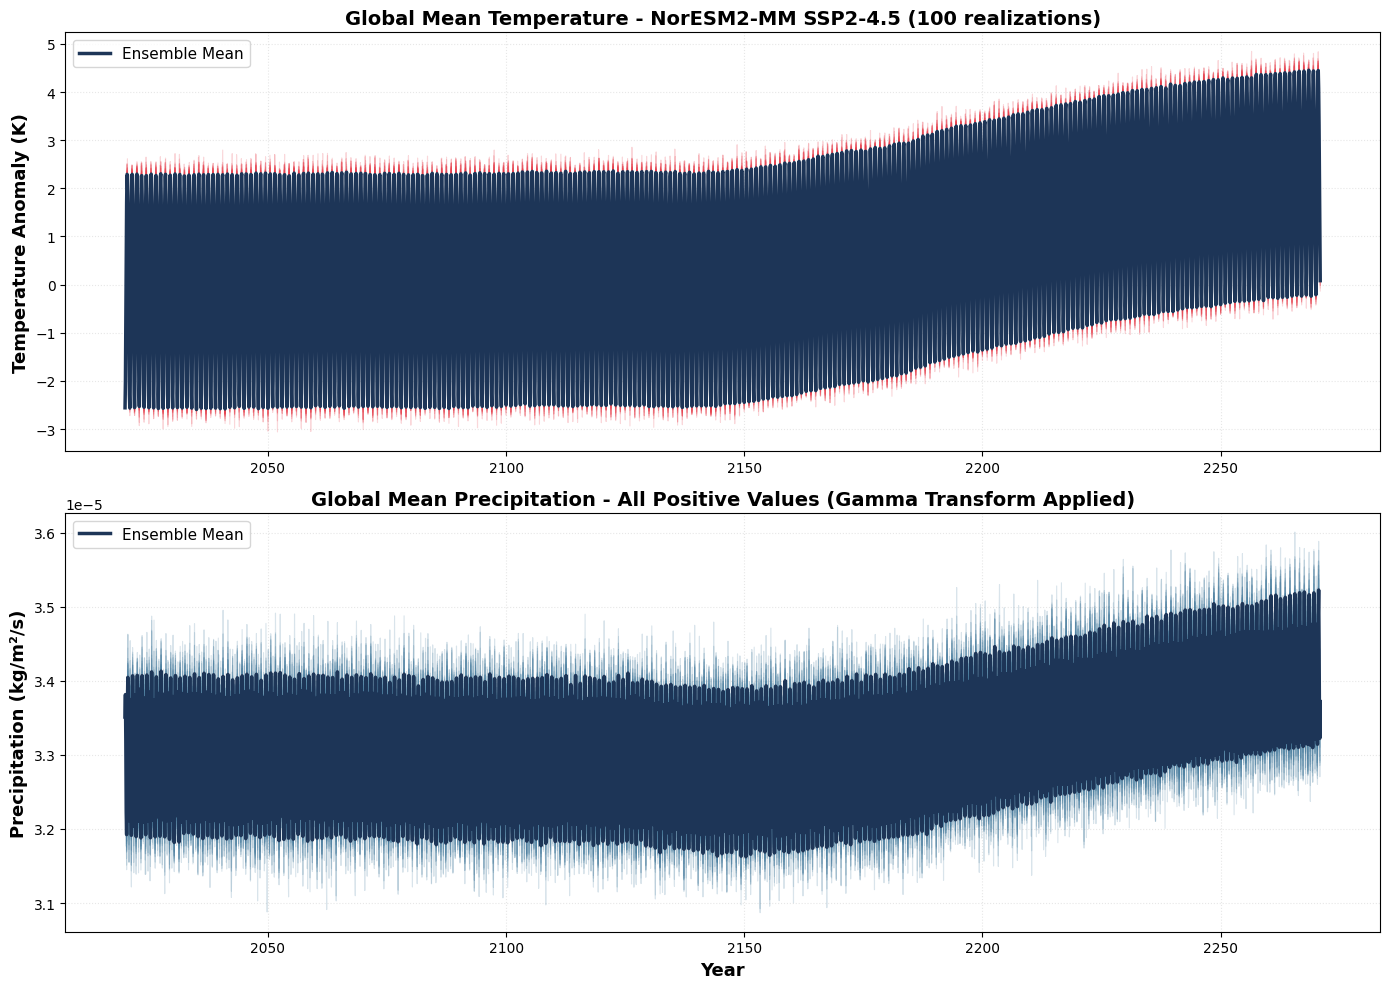

Temperature range: -3.15 to 4.95 K
Precipitation range: 0.000031 to 0.000036 kg/m²/s
Precipitation all positive: <xarray.DataArray ()> Size: 1B
array(True)


In [7]:
# Extract global data
tas_global = ensemble['tas'].timeseries['global']
pr_global = ensemble['pr'].timeseries['global']

# Create time axis (monthly)
n_months = tas_global.shape[1]
years = 2020 + np.arange(n_months) / 12

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Temperature
for i in range(min(20, tas_global.shape[0])):  # Plot 20 ensemble members
    ax1.plot(years, tas_global[i, :], color='#E63946', alpha=0.2, linewidth=0.8)
tas_mean = tas_global.mean(axis=0)
ax1.plot(years, tas_mean, color='#1D3557', linewidth=2.5, label='Ensemble Mean')
ax1.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax1.set_title('Global Mean Temperature - NorESM2-MM SSP2-4.5 (100 realizations)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax1.legend(fontsize=11)


# Precipitation (convert to mm/day if needed)
for i in range(min(20, pr_global.shape[0])):
    ax2.plot(years, pr_global[i, :], color='#457B9D', alpha=0.2, linewidth=0.8)
pr_mean = pr_global.mean(axis=0)
ax2.plot(years, pr_mean, color='#1D3557', linewidth=2.5, label='Ensemble Mean')
ax2.set_xlabel('Year', fontsize=13, fontweight='bold')
ax2.set_ylabel('Precipitation (kg/m²/s)', fontsize=13, fontweight='bold')
ax2.set_title('Global Mean Precipitation - All Positive Values (Gamma Transform Applied)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Temperature range: {float(tas_global.min()):.2f} to {float(tas_global.max()):.2f} K")
print(f"Precipitation range: {float(pr_global.min()):.6f} to {float(pr_global.max()):.6f} kg/m²/s")
print(f"Precipitation all positive: {(pr_global >= 0).all()}")

## 6. Plot 2: Regional Temperature and Precipitation

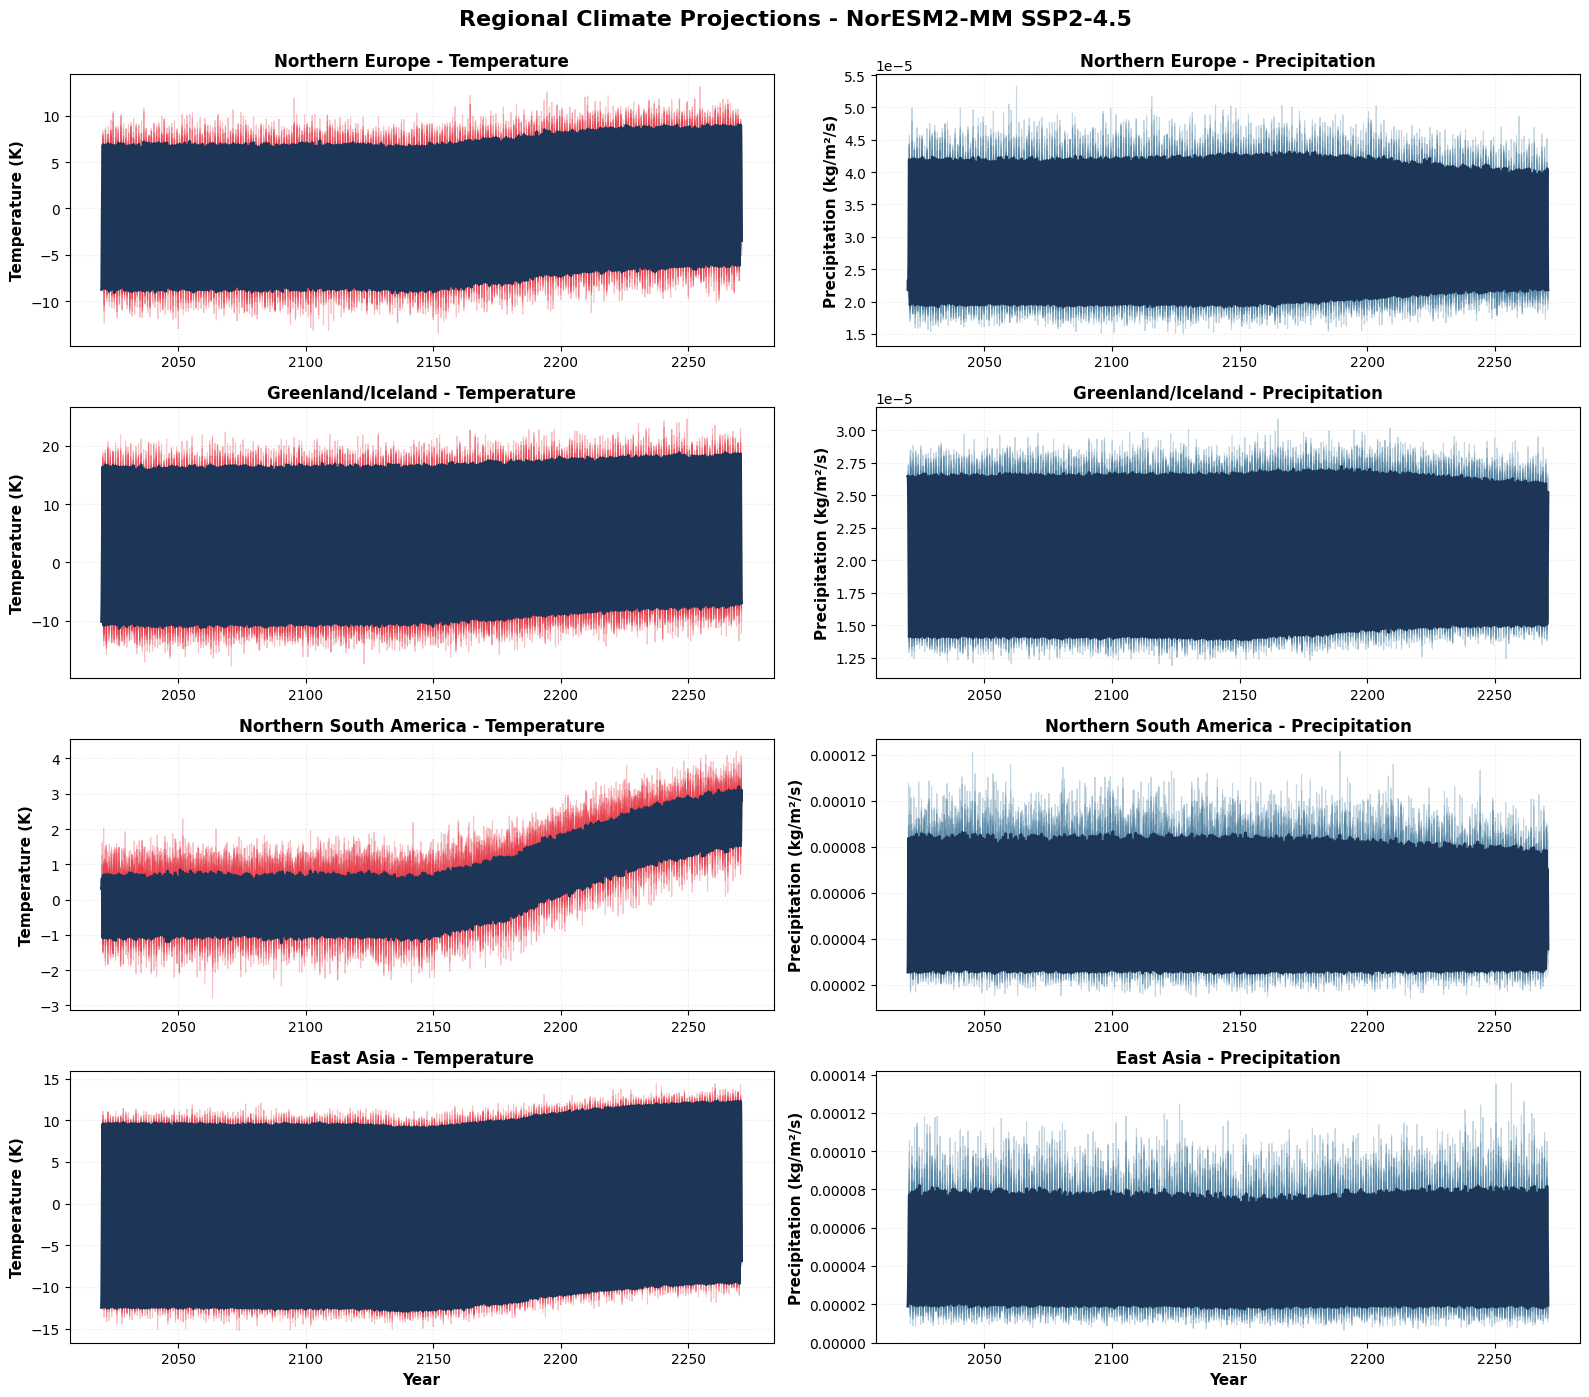

In [8]:
# Create 4x2 grid (4 regions, temp + precip)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Regional Climate Projections - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

for i, region in enumerate(regions):
    # Get data
    tas_reg = ensemble['tas'].timeseries[f'regional:{region}']
    pr_reg = ensemble['pr'].timeseries[f'regional:{region}']
    
    # Temperature (left column)
    ax_t = axes[i, 0]
    for j in range(min(10, tas_reg.shape[0])):
        ax_t.plot(years, tas_reg[j, :], color='#E63946', alpha=0.3, linewidth=0.8)
    ax_t.plot(years, tas_reg.mean(axis=0), color='#1D3557', linewidth=2, label='Mean')
    ax_t.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f"{region_names[region]} - Temperature", fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    if i == 3:
        ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
    
    # Precipitation (right column)
    ax_p = axes[i, 1]
    for j in range(min(10, pr_reg.shape[0])):
        ax_p.plot(years, pr_reg[j, :], color='#457B9D', alpha=0.3, linewidth=0.8)
    ax_p.plot(years, pr_reg.mean(axis=0), color='#1D3557', linewidth=2, label='Mean')
    ax_p.set_ylabel('Precipitation (kg/m²/s)', fontsize=11, fontweight='bold')
    ax_p.set_title(f"{region_names[region]} - Precipitation", fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    if i == 3:
        ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Plot 3: City-Scale Temperature and Precipitation

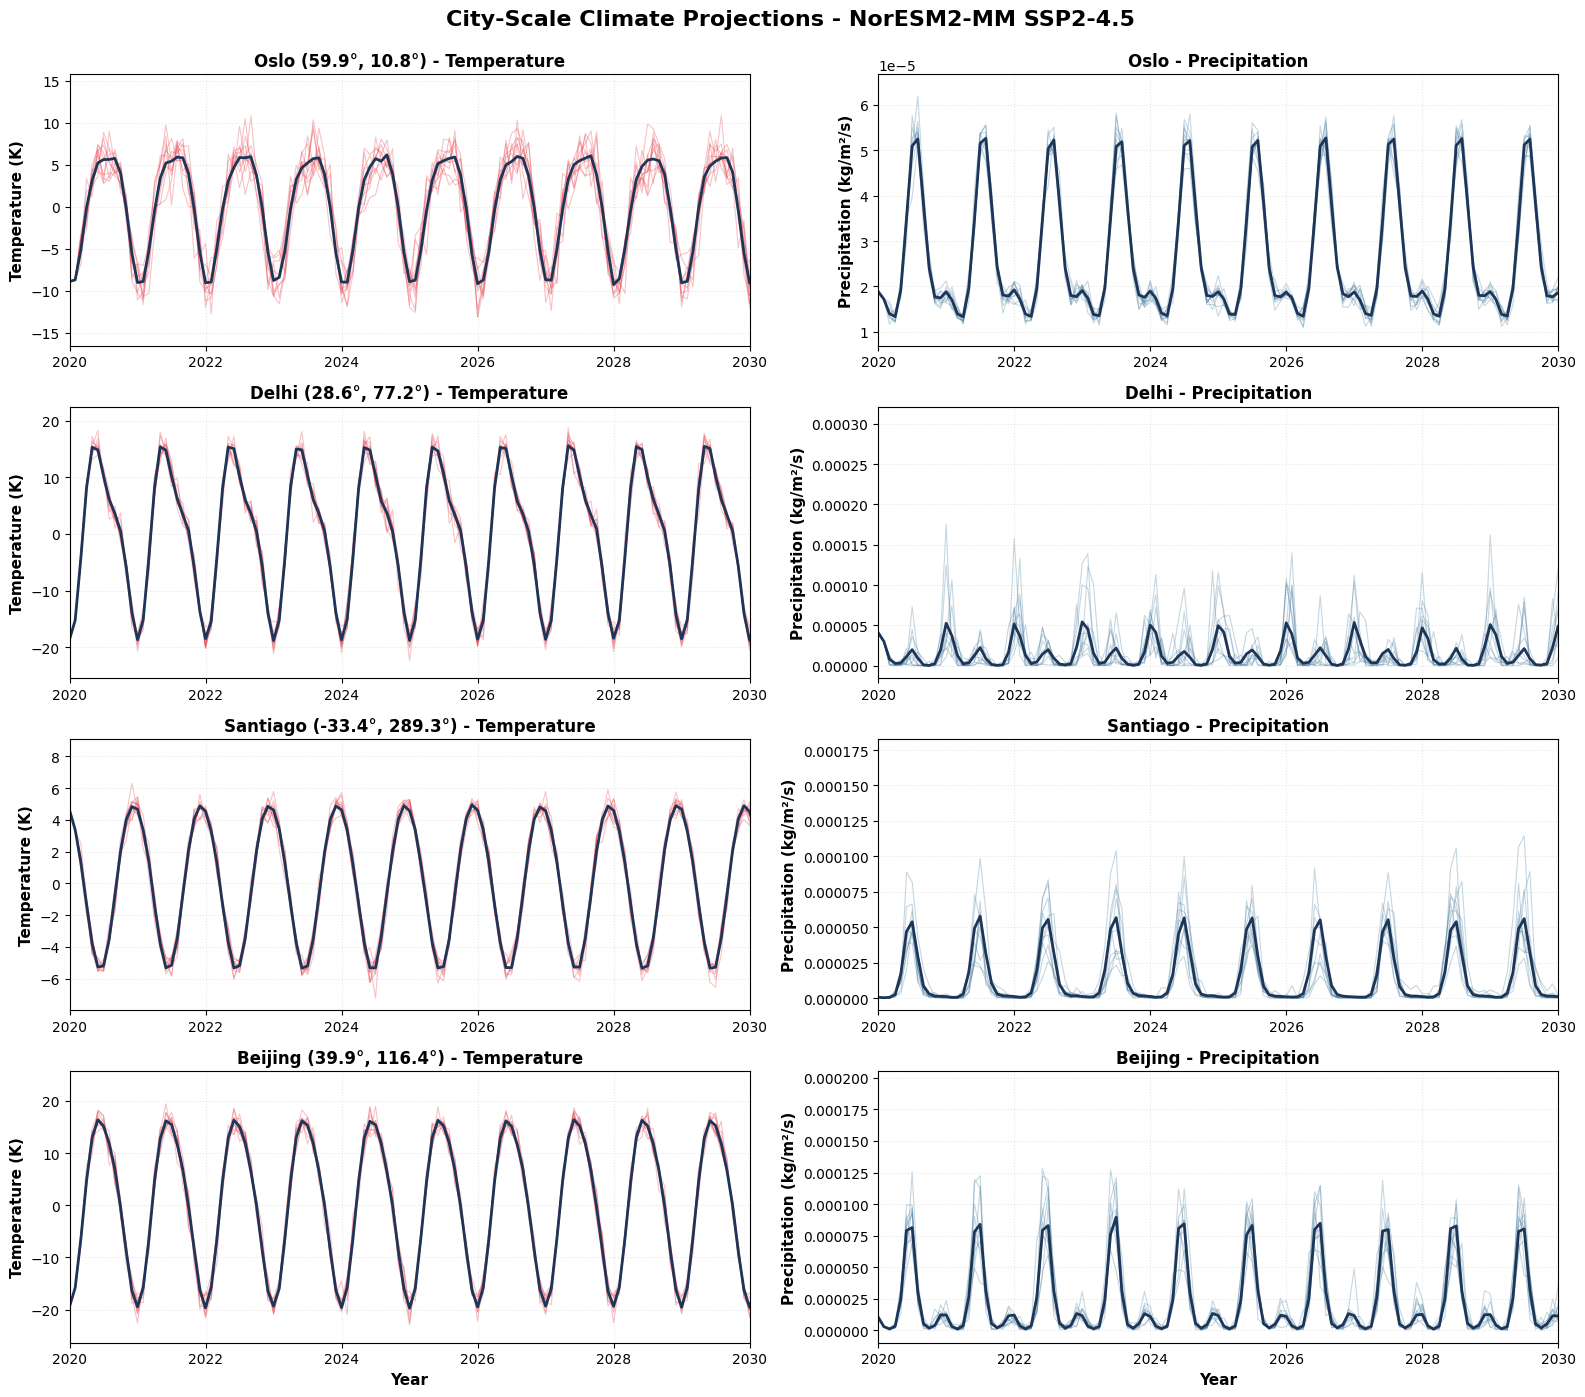

In [9]:
# Create 4x2 grid (4 cities, temp + precip)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('City-Scale Climate Projections - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

city_list = list(cities.keys())

for i, city in enumerate(city_list):
    # Build point key
    point_key = f"point:{cities[city]['lat']},{cities[city]['lon']}"
    
    # Get data
    tas_city = ensemble['tas'].timeseries[point_key]
    pr_city = ensemble['pr'].timeseries[point_key]
    
    # Temperature (left column)
    ax_t = axes[i, 0]
    for j in range(min(10, tas_city.shape[0])):
        ax_t.plot(years, tas_city[j, :], color='#E63946', alpha=0.3, linewidth=0.8)
    ax_t.plot(years, tas_city.mean(axis=0), color='#1D3557', linewidth=2, label='Mean')
    ax_t.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f"{city} ({cities[city]['lat']:.1f}°, {cities[city]['lon']:.1f}°) - Temperature", 
                   fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    ax_t.set_xlim([2020,2030])

    if i == 3:
        ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
    
    # Precipitation (right column)
    ax_p = axes[i, 1]
    for j in range(min(10, pr_city.shape[0])):
        ax_p.plot(years, pr_city[j, :], color='#457B9D', alpha=0.3, linewidth=0.8)
    ax_p.plot(years, pr_city.mean(axis=0), color='#1D3557', linewidth=2, label='Mean')
    ax_p.set_ylabel('Precipitation (kg/m²/s)', fontsize=11, fontweight='bold')
    ax_p.set_title(f"{city} - Precipitation", fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    if i == 3:
        ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax_p.set_xlim([2020,2030])
plt.tight_layout()
plt.show()

## 8. Ensemble Adequacy Test

Test if 100 realizations are sufficient by comparing statistics from different ensemble subsets.
We'll test for each region, for both temperature and precipitation.

In [10]:
def ensemble_adequacy_test(data, n_tests=20, subset_size=50):
    """
    Test ensemble adequacy by comparing statistics from random subsets.
    
    Returns:
        mean_std: Standard deviation of means from different subsets
        std_std: Standard deviation of stds from different subsets
    """
    n_realizations = data.shape[0]
    
    subset_means = []
    subset_stds = []
    
    for _ in range(n_tests):   
        # Random subset
        idx = np.random.choice(n_realizations, subset_size, replace=False)
        subset = data[idx, :]
           
        subset_means.append(float(subset.mean()))
        subset_stds.append(float(subset.std()))
    
    return np.std(subset_means), np.std(subset_stds)

print("Testing ensemble adequacy (100 realizations, 20 tests with 50-member subsets)...\n")
 
print("GLOBAL:")
tas_mean_std, tas_std_std = ensemble_adequacy_test(ensemble['tas'].timeseries['global'])
pr_mean_std, pr_std_std = ensemble_adequacy_test(ensemble['pr'].timeseries['global'])
print(f"  TAS - Mean variability: {tas_mean_std:.4f}, Std variability: {tas_std_std:.4f}")
print(f"  PR  - Mean variability: {pr_mean_std:.6f}, Std variability: {pr_std_std:.6f}")

# Test for each region
for region in regions:
    print(f"\n{region_names[region].upper()}:")
    tas_data = ensemble['tas'].timeseries[f'regional:{region}']
    pr_data = ensemble['pr'].timeseries[f'regional:{region}']
    
    tas_mean_std, tas_std_std = ensemble_adequacy_test(tas_data)
    pr_mean_std, pr_std_std = ensemble_adequacy_test(pr_data)
    
    print(f"  TAS - Mean variability: {tas_mean_std:.4f}, Std variability: {tas_std_std:.4f}")
    print(f"  PR  - Mean variability: {pr_mean_std:.6f}, Std variability: {pr_std_std:.6f}")

print("\n✅ Low variability indicates sufficient ensemble size")

Testing ensemble adequacy (100 realizations, 20 tests with 50-member subsets)...

GLOBAL:
  TAS - Mean variability: 0.0004, Std variability: 0.0002
  PR  - Mean variability: 0.000000, Std variability: 0.000000

NORTHERN EUROPE:
  TAS - Mean variability: 0.0024, Std variability: 0.0024
  PR  - Mean variability: 0.000000, Std variability: 0.000000

GREENLAND/ICELAND:
  TAS - Mean variability: 0.0032, Std variability: 0.0023
  PR  - Mean variability: 0.000000, Std variability: 0.000000

NORTHERN SOUTH AMERICA:
  TAS - Mean variability: 0.0012, Std variability: 0.0007
  PR  - Mean variability: 0.000000, Std variability: 0.000000

EAST ASIA:
  TAS - Mean variability: 0.0010, Std variability: 0.0009
  PR  - Mean variability: 0.000000, Std variability: 0.000000

✅ Low variability indicates sufficient ensemble size


In [11]:
## 9. Rank Histogram Analysis

# First, we need to load CMIP6 data for comparison
print("Loading CMIP6 data for ensemble adequacy test...")

from meteor import Cmip6MeteorDataGetter, prpatt

# Initialize data getter
data_getter = Cmip6MeteorDataGetter(
    exps=["historical", "ssp245"],
    flds=['tas', 'pr'],
    dbe=['CMIP', 'ScenarioMIP'],
    enable_cache=True
)

# Load CMIP6 data (monthly)
cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"],
    emulator.model,
    monthly=True
)

# Calculate spatial aggregations matching our ensemble
cmip6_timeseries = {'tas': {}, 'pr': {}}

for variable in ['tas', 'pr']:
    # Global
    cmip6_timeseries[variable]['global'] = prpatt.global_mean(cmip6_data_raw[variable])
    
    # Regions
    for region in regions:
        cmip6_timeseries[variable][f'regional:{region}'] = prpatt.regional_mean(
            cmip6_data_raw[variable], region
        )

print(f"✅ CMIP6 data loaded")
print(f"   TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"   PR shape: {cmip6_data_raw['pr'].shape}")

Loading CMIP6 data for ensemble adequacy test...


✅ CMIP6 data loaded
   TAS shape: (1, 3012, 192, 288)
   PR shape: (1, 3012, 192, 288)


In [12]:
## 9. Rank Histogram Analysis (FIXED - Matching Baselines)

# First, we need to load CMIP6 data for comparison
print("Loading CMIP6 data for ensemble adequacy test...")

from meteor import Cmip6MeteorDataGetter, prpatt

# Initialize data getter
data_getter = Cmip6MeteorDataGetter(
    exps=["historical", "ssp245"],
    flds=['tas', 'pr'],
    dbe=['CMIP', 'ScenarioMIP'],
    enable_cache=True
)

# Load CMIP6 data (monthly) - THIS IS ABSOLUTE TEMPERATURE
cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"],
    emulator.model,
    monthly=True
)

# Load piControl to get baseline for converting to anomalies
print("Loading piControl baseline...")
picontrol_data = data_getter.make_meteor_training_data(
    "piControl",
    emulator.model,
    monthly=True
)

# Calculate spatial aggregations matching our ensemble
cmip6_timeseries = {'tas': {}, 'pr': {}}
picontrol_baselines = {'tas': {}, 'pr': {}}

for variable in ['tas', 'pr']:
    # Global - convert CMIP6 to anomalies
    cmip6_global_abs = prpatt.global_mean(cmip6_data_raw[variable])
    picontrol_global = prpatt.global_mean(picontrol_data[variable])
    picontrol_baseline = picontrol_global.mean()
    
    # Store anomalies (CMIP6 - piControl baseline)
    if variable == 'tas':
        cmip6_timeseries[variable]['global'] = cmip6_global_abs - picontrol_baseline
    else:
        cmip6_timeseries[variable]['global'] = cmip6_global_abs
    picontrol_baselines[variable]['global'] = float(picontrol_baseline.values)
    
    # Regions - convert to anomalies
    for region in regions:
        cmip6_reg_abs = prpatt.regional_mean(cmip6_data_raw[variable], region)
        picontrol_reg = prpatt.regional_mean(picontrol_data[variable], region)
        picontrol_baseline_reg = picontrol_reg.mean()
        if variable == 'tas':
            cmip6_timeseries[variable][f'regional:{region}'] = cmip6_reg_abs - picontrol_baseline_reg
        else:
            cmip6_timeseries[variable][f'regional:{region}'] = cmip6_reg_abs
        picontrol_baselines[variable][f'regional:{region}'] = float(picontrol_baseline_reg.values)

print(f"✅ CMIP6 data loaded and converted to anomalies")
print(f"   TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"   PR shape: {cmip6_data_raw['pr'].shape}")
print(f"\nBaselines (piControl mean):")
for var in ['tas', 'pr']:
    print(f"  {var} global: {picontrol_baselines[var]['global']:.4f}")

Loading CMIP6 data for ensemble adequacy test...
Loading piControl baseline...
Loading piControl baseline...
✅ CMIP6 data loaded and converted to anomalies
   TAS shape: (1, 3012, 192, 288)
   PR shape: (1, 3012, 192, 288)

Baselines (piControl mean):
  tas global: 286.9248
  pr global: 0.0000
✅ CMIP6 data loaded and converted to anomalies
   TAS shape: (1, 3012, 192, 288)
   PR shape: (1, 3012, 192, 288)

Baselines (piControl mean):
  tas global: 286.9248
  pr global: 0.0000


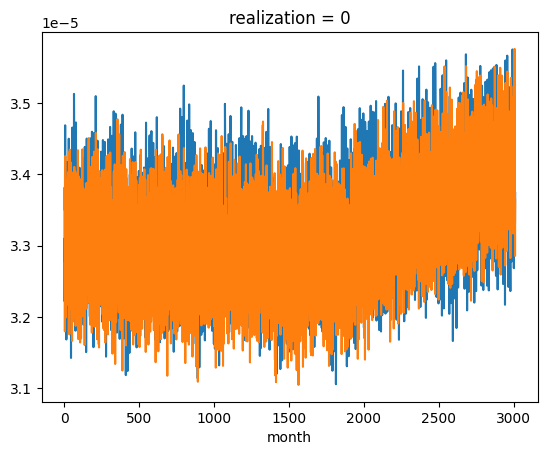

In [13]:
cmip6_timeseries['pr']['global'].plot()
ensemble['pr'].timeseries['global'][0,:].plot.line(x='month')

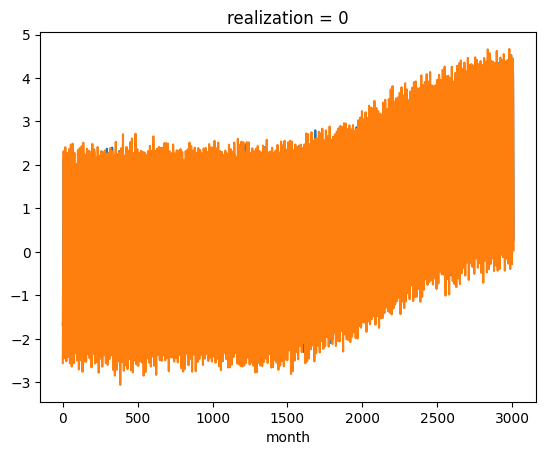

In [14]:
cmip6_timeseries['tas']['global'].plot()
ensemble['tas'].timeseries['global'][0,:].plot.line(x='month')

In [15]:
print(f"Emulated global mean (first realization, first value): {ensemble['tas'].timeseries['global'][0, 0]:.4f} K")
print(f"CMIP6 global mean (first member, matching time): {cmip6_timeseries['tas']['global'].values[0, -972]:.4f} K")  
print(f"Difference: {cmip6_timeseries['tas']['global'].values[0, -972] - ensemble['tas'].timeseries['global'][0, 0]:.4f} K")

Emulated global mean (first realization, first value): -2.5588 K
CMIP6 global mean (first member, matching time): -0.8025 K
Difference: 1.7563 K


Computing rank histograms...

DEBUG tas global:
  Emulated shape: (100, 3012)
  CMIP6 shape: (1, 3012)
  Emulated range: [-3.1481, 4.9495]
  Emulated std: 1.8909
  CMIP6 subset shape: (1, 3012)
  CMIP6 range: [-2.4684, 4.5259]
  CMIP6 std: 1.6302

DEBUG tas global:
  Number of ranks: 3012

DEBUG tas global:
  Number of ranks: 3012
  Rank range: [0.000, 1.000]
  Rank mean: 0.533 (should be ~0.5)
  Rank std: 0.443
  Rank range: [0.000, 1.000]
  Rank mean: 0.533 (should be ~0.5)
  Rank std: 0.443

DEBUG tas regional:NEU:
  Number of ranks: 3012

DEBUG tas regional:NEU:
  Number of ranks: 3012
  Rank range: [0.000, 1.000]
  Rank mean: 0.495 (should be ~0.5)
  Rank std: 0.333
  Rank range: [0.000, 1.000]
  Rank mean: 0.495 (should be ~0.5)
  Rank std: 0.333


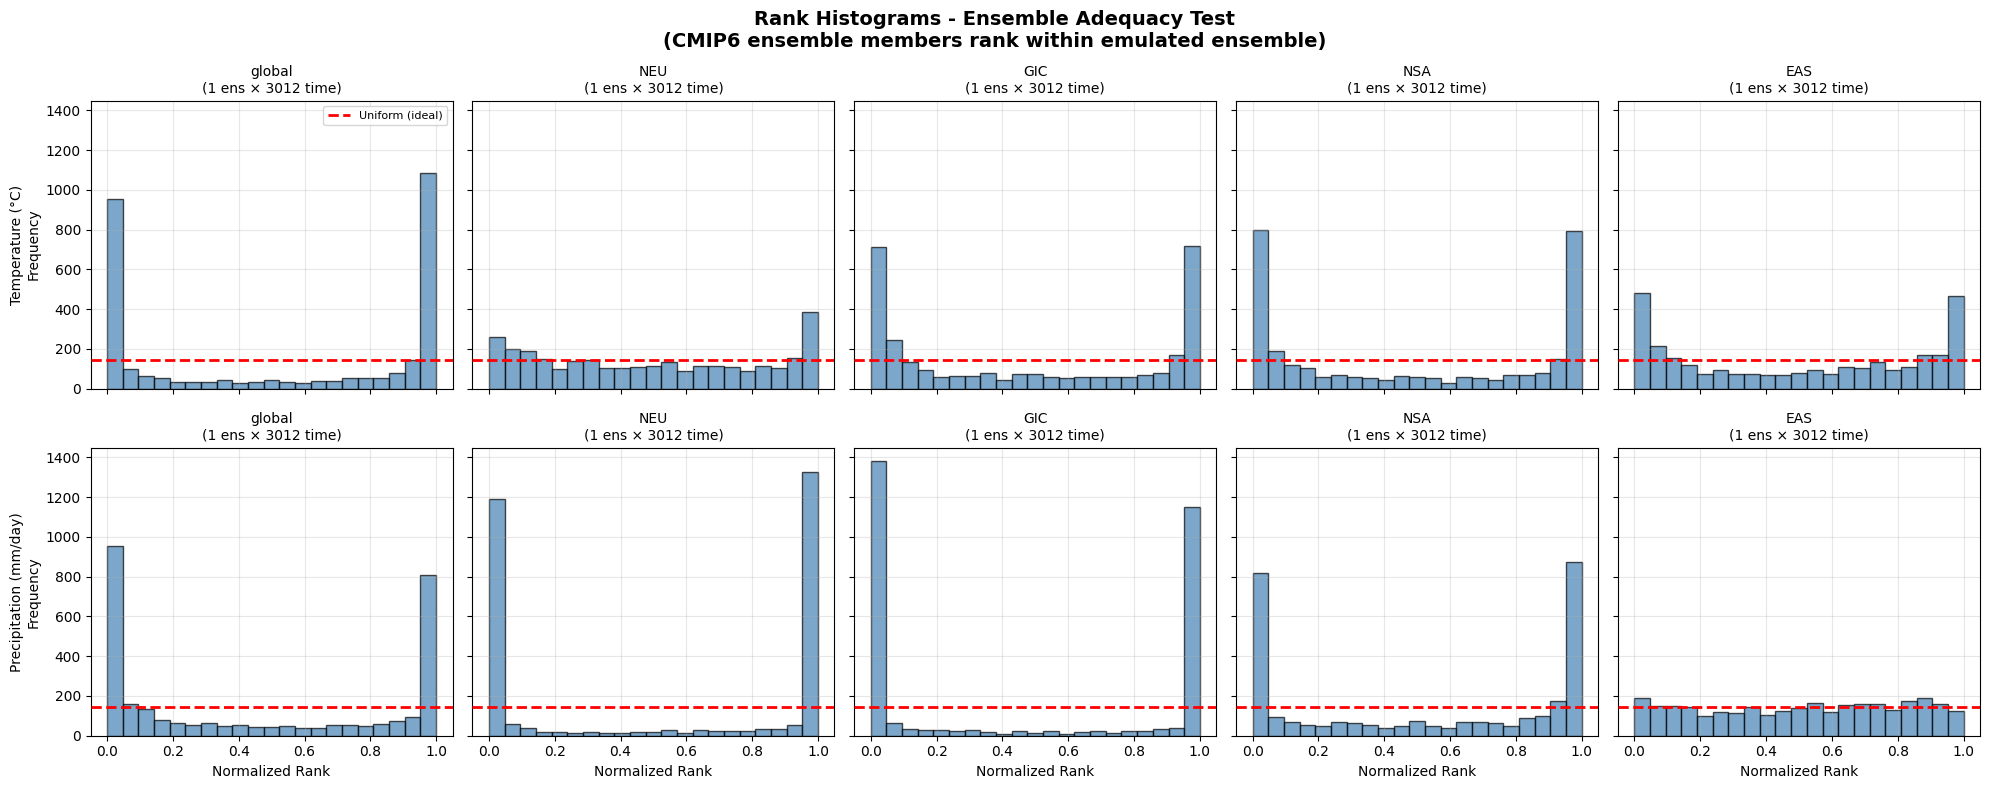


✅ Rank histograms complete

💡 Interpretation:
   - Uniform distribution → Emulated ensemble adequately spans CMIP6 variability
   - U-shaped → Under-dispersed (emulated ensemble too narrow)
   - Dome-shaped → Over-dispersed (emulated ensemble too wide)


In [16]:
# Rank Histogram Analysis with Diagnostics
print("Computing rank histograms...")

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
fig.suptitle('Rank Histograms - Ensemble Adequacy Test\n(CMIP6 ensemble members rank within emulated ensemble)', 
             fontsize=14, fontweight='bold')

n_bins = 21  # Number of bins for rank histogram

for var_idx, variable in enumerate(['tas', 'pr']):
    for loc_idx, loc in enumerate(['global', 'regional:NEU', 'regional:GIC', 'regional:NSA', 'regional:EAS']):
        ax = axes[var_idx, loc_idx]
        
        # Get emulated ensemble data
        emulated_data = ensemble[variable].timeseries[loc]  # shape: (n_realizations, n_timesteps)
        n_realizations = emulated_data.shape[0]
        
        # Get CMIP6 data
        cmip6_data = cmip6_timeseries[variable][loc]
        
        # Align time periods
        n_time_emulated = emulated_data.shape[1]
        
        # DEBUG: Print shapes and statistics
        if loc_idx == 0 and var_idx == 0:
            print(f"\nDEBUG {variable} {loc}:")
            print(f"  Emulated shape: {emulated_data.shape}")
            print(f"  CMIP6 shape: {cmip6_data.shape}")
            print(f"  Emulated range: [{emulated_data.min():.4f}, {emulated_data.max():.4f}]")
            print(f"  Emulated std: {emulated_data.std():.4f}")
        
        if cmip6_data.values.ndim == 2:
            # Multiple ensemble members
            cmip6_subset = cmip6_data.values[:, -n_time_emulated:]
            n_ens = cmip6_subset.shape[0]
        else:
            # Single member - reshape to (1, time)
            cmip6_subset = cmip6_data.values[-n_time_emulated:][None, :]
            n_ens = 1
        
        # DEBUG: Print CMIP6 statistics
        if loc_idx == 0 and var_idx == 0:
            print(f"  CMIP6 subset shape: {cmip6_subset.shape}")
            print(f"  CMIP6 range: [{cmip6_subset.min():.4f}, {cmip6_subset.max():.4f}]")
            print(f"  CMIP6 std: {cmip6_subset.std():.4f}")
        
        # Calculate ranks (NORMALIZED to 0-1 like original)
        ranks = []
        for ens_idx in range(n_ens):
            for t in range(cmip6_subset.shape[1]):
                ensemble_at_t = emulated_data[:, t]  # (n_realizations,)
                cmip6_value = float(cmip6_subset[ens_idx, t])
                
                # Count how many emulated members are below CMIP6 value
                count_below = np.sum(ensemble_at_t < cmip6_value)
                
                # NORMALIZE to get rank in [0, 1] range
                normalized_rank = count_below / n_realizations
                ranks.append(normalized_rank)
        
        # DEBUG: Print rank statistics
        if loc_idx <= 1 and var_idx == 0:
            print(f"\nDEBUG {variable} {loc}:")
            print(f"  Number of ranks: {len(ranks)}")
            print(f"  Rank range: [{min(ranks):.3f}, {max(ranks):.3f}]")
            print(f"  Rank mean: {np.mean(ranks):.3f} (should be ~0.5)")
            print(f"  Rank std: {np.std(ranks):.3f}")
        
        # Plot histogram with bins from 0 to 1
        counts, bins, patches = ax.hist(ranks, bins=n_bins, range=(0, 1), 
                                        color='steelblue', edgecolor='black', alpha=0.7)
        
        # Add uniform distribution reference line
        expected_count = len(ranks) / n_bins
        ax.axhline(expected_count, color='red', linestyle='--', linewidth=2, 
                   label='Uniform (ideal)', zorder=10)
        
        # Formatting
        label = f"{loc.split(':')[1] if ':' in loc else loc}"
        ax.set_title(f'{label}\n({n_ens} ens × {cmip6_subset.shape[1]} time)', 
                    fontsize=10)
        
        if var_idx == 1:
            ax.set_xlabel('Normalized Rank', fontsize=10)
        if loc_idx == 0:
            ylabel = 'Temperature (°C)' if variable == 'tas' else 'Precipitation (mm/day)'
            ax.set_ylabel(f'{ylabel}\nFrequency', fontsize=10)
        
        ax.grid(True, alpha=0.3)
        
        if var_idx == 0 and loc_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Rank histograms complete")
print("\n💡 Interpretation:")
print("   - Uniform distribution → Emulated ensemble adequately spans CMIP6 variability")
print("   - U-shaped → Under-dispersed (emulated ensemble too narrow)")
print("   - Dome-shaped → Over-dispersed (emulated ensemble too wide)")

## 9. Heating Degree Days Analysis

Analyze heating degree days (HDD) for the four regions.
HDD measures heating energy demand (days × degrees below base temperature).

KeyError: 'hdd'

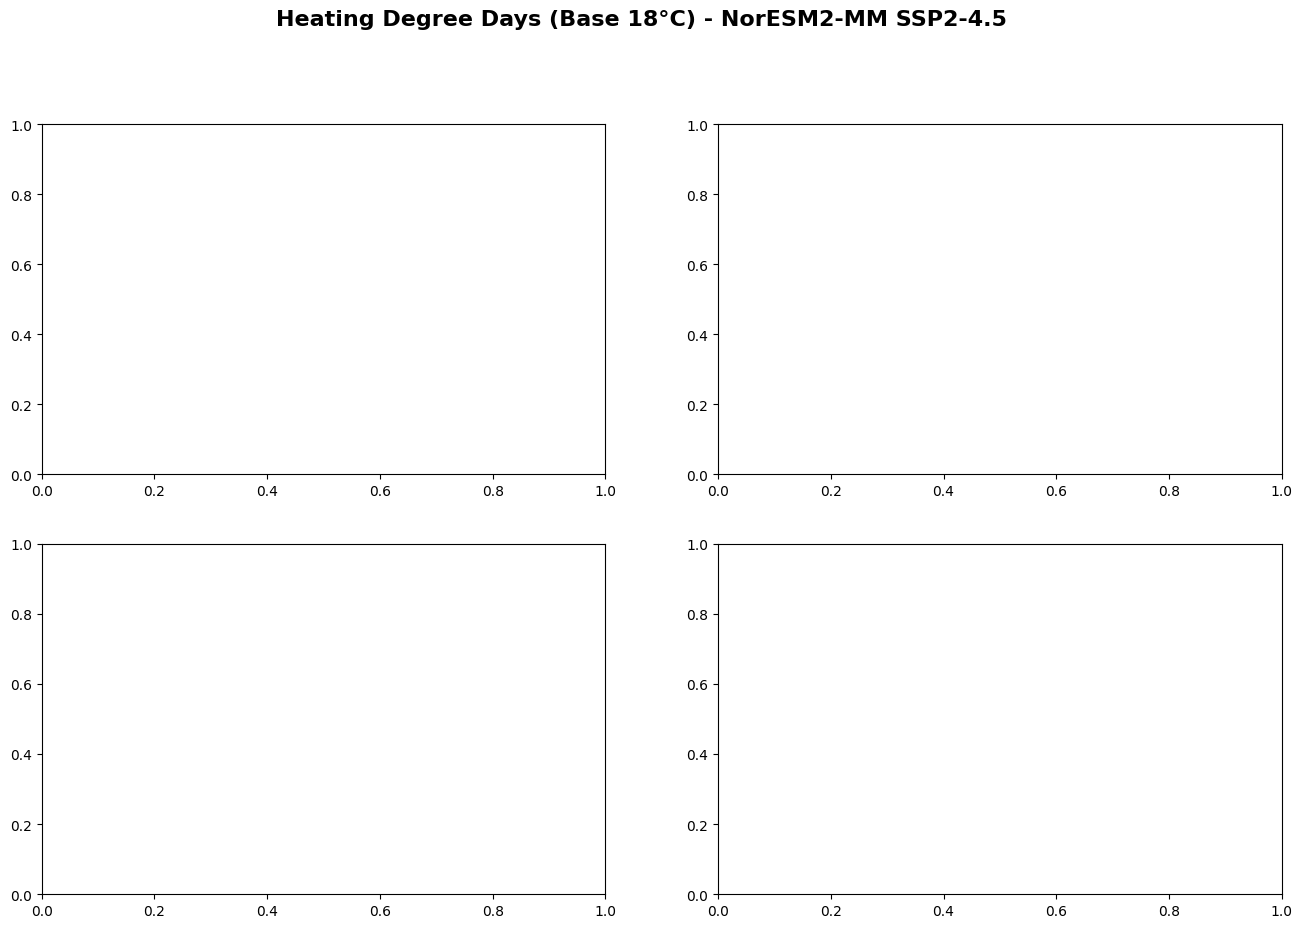

In [17]:
# Create 2x2 grid for HDD in four regions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Heating Degree Days (Base 18°C) - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for i, region in enumerate(regions):
    # Get HDD data
    hdd_data = ensemble['tas'].impacts['hdd'][f'regional:{region}']
    
    ax = axes[i]
    
    # Plot ensemble members
    for j in range(min(20, hdd_data.shape[0])):
        ax.plot(years, hdd_data[j, :], color='#F4A261', alpha=0.2, linewidth=0.8)
    
    # Plot ensemble mean
    hdd_mean = hdd_data.mean(axis=0)
    ax.plot(years, hdd_mean, color='#E76F51', linewidth=2.5, label='Ensemble Mean')
    
    # Calculate trend
    z = np.polyfit(years, hdd_mean, 1)
    trend = z[0] * (2100 - 2020)  # Total change over period
    
    ax.set_title(f"{region_names[region]} (Trend: {trend:.0f} HDD/century)", 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Heating Degree Days', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Heating Degree Days Summary (2020 vs 2100):")
for region in regions:
    hdd_data = ensemble['tas'].impacts['hdd'][f'regional:{region}']
    hdd_2020 = hdd_data[:, :12].mean()  # First year
    hdd_2100 = hdd_data[:, -12:].mean()  # Last year
    change = ((hdd_2100 - hdd_2020) / hdd_2020) * 100
    print(f"  {region_names[region]:25s}: {float(hdd_2020):6.0f} → {float(hdd_2100):6.0f} ({change:+.1f}%)")

## 10. Summary Statistics

In [ ]:
print("="*70)
print("METEOR Interface Demo - Summary")
print("="*70)

print(f"\nModel: NorESM2-MM")
print(f"Scenario: SSP2-4.5")
print(f"Period: 2020-2100")
print(f"Ensemble size: 100 realizations")

print(f"\nVariables generated:")
print(f"  - Temperature (tas): No transform")
print(f"  - Precipitation (pr): Gamma transform (all values positive ✓)")

print(f"\nSpatial aggregations:")
print(f"  - Global mean")
print(f"  - {len(regions)} regions: {', '.join(regions)}")
print(f"  - {len(cities)} cities: {', '.join(cities.keys())}")

print(f"\nImpact metrics:")
print(f"  - Heating Degree Days (HDD, base 18°C)")
print(f"  - Cooling Degree Days (CDD, base 18°C)")

print(f"\nPrecipitation transform validation:")
all_positive = True
for key in ensemble['pr'].timeseries.keys():
    data = ensemble['pr'].timeseries[key]
    is_positive = (data >= 0).all()
    all_positive = all_positive and is_positive
    print(f"  {key:30s}: Min = {float(data.min()):.6f} (all positive: {is_positive})")

print(f"\n✅ All precipitation values positive: {all_positive}")
print("\n" + "="*70)
print("Demo complete!")
print("="*70)